## Predicting Consumer Loan Defaults
### Comparative models
- Logistic Regression
- Random Forest
- XGBoost
  
### Methodological design
- Class imbalance handled through cost-sensitive learning
- Five-fold stratified cross-validation
- Model selection using mean cross-validated ROC-AUC
- Final evaluation on a held-out 20% test set
- SHAP interpretation for the selected model

In [1]:
import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb
import shap
import matplotlib

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)
print("SHAP:", shap.__version__)
print("Matplotlib:", matplotlib.__version__)

print("\nAll required packages imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Pandas: 3.0.5
NumPy: 2.4.6
Scikit-learn: 1.9.0
XGBoost: 3.4.0
SHAP: 0.52.0
Matplotlib: 3.11.1

All required packages imported successfully.


In [2]:
# File and folder operations
import os

# Clean feature names
import re

# Measure model runtime
import time

# Record the Python version
import platform

# Display warning messages when necessary
import warnings

# Numerical operations
import numpy as np

# Data handling
import pandas as pd

# Charts
import matplotlib.pyplot as plt

# Save the fitted model
import joblib

# Record package versions
import sklearn
import xgboost
import shap

# Data splitting and cross-validation
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict,
)

# Modelling pipelines
from sklearn.pipeline import Pipeline

# Missing-value treatment
from sklearn.impute import SimpleImputer

# Feature scaling
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

# Display charts inside the notebook
%matplotlib inline

# Keep warnings visible initially.
# If you later receive harmless repeated warnings, you can change this.
warnings.filterwarnings("default")

# Source dataset
DATA_FILE = "application_train.csv"

# Output folder
OUTPUT_FOLDER = "figures"

# Create the output folder
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Reproducibility settings
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_FOLDS = 5

# SHAP settings
SHAP_SAMPLE_SIZE = 1000

# Primary model-selection measure
PRIMARY_METRIC = "roc_auc"

print("Notebook environment is ready.")

Notebook environment is ready.


In [4]:
package_versions = {
    "Python": platform.python_version(),
    "NumPy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "scikit-learn": sklearn.__version__,
    "XGBoost": xgboost.__version__,
    "SHAP": shap.__version__,
}

version_table = pd.DataFrame(
    package_versions.items(),
    columns=["Package", "Version"],
)

version_table.to_csv(
    os.path.join(OUTPUT_FOLDER, "package_versions.csv"),
    index=False,
)

display(version_table)

,Package,Version
0,Python,3.12.13
1,NumPy,2.4.6
2,pandas,3.0.5
3,matplotlib,3.11.1
4,scikit-learn,1.9.0
5,XGBoost,3.4.0
6,SHAP,0.52.0


In [5]:

# Load the dataset
df = pd.read_csv(DATA_FILE)

print(f"Loaded {df.shape,} rows and {df.shape,} columns.")

# Variables required by the analysis
required_columns = {
    "TARGET",
    "SK_ID_CURR",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CODE_GENDER",
}

# Identify missing required columns
missing_required_columns = required_columns.difference(df.columns)

if missing_required_columns:
    raise KeyError(
        "The following required columns are missing: "
        f"{sorted(missing_required_columns)}"
    )

# Confirm that TARGET contains only zero and one
target_values = set(df["TARGET"].dropna().unique())

if target_values != {0, 1}:
    raise ValueError(
        "TARGET must contain only 0 and 1. "
        f"Observed values: {sorted(target_values)}"
    )

# Confirm that applicant IDs are unique
if not df["SK_ID_CURR"].is_unique:
    raise ValueError(
        "SK_ID_CURR contains duplicate applicant identifiers."
    )

display(df.head())

Loaded ((307511, 122),) rows and ((307511, 122),) columns.


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Create a flag for the unusual DAYS_EMPLOYED placeholder
df["EMPLOYED_ANOMALY"] = (
    df["DAYS_EMPLOYED"] == 365243
).astype(int)

# Replace the placeholder with a genuine missing value
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(
    365243,
    np.nan,
)

# I remove the very small number of CODE_GENDER = XNA records
rows_before_filtering = len(df)

df = df.loc[
    df["CODE_GENDER"] != "XNA"
].copy()

rows_removed = rows_before_filtering - len(df)

print(
    f"Removed {rows_removed:,} observation(s) "
    "with CODE_GENDER recorded as XNA."
)

# Confirm that TARGET remains complete
if df["TARGET"].isna().any():
    raise ValueError("TARGET contains missing values after cleaning.")

print(f"Data remaining after cleaning: {len(df):,} rows.")

C:\Users\USER\AppData\Local\Temp\ipykernel_18660\3134397836.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EMPLOYED_ANOMALY"] = (


Removed 4 observation(s) with CODE_GENDER recorded as XNA.
Data remaining after cleaning: 307,507 rows.


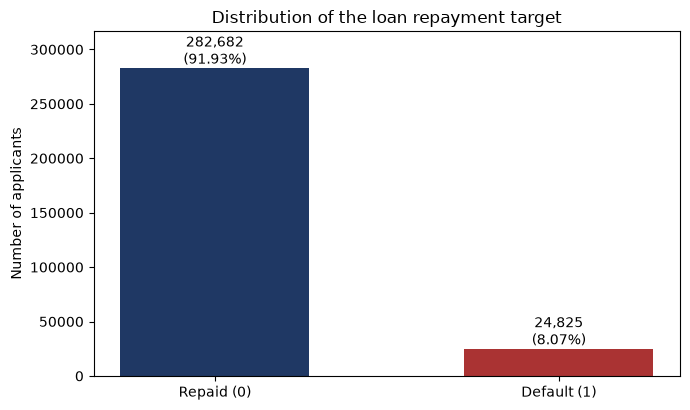

,Count,Percentage
TARGET,,
0,282682,91.927013
1,24825,8.072987


In [8]:
# Count observations in each target class
target_counts = (
    df["TARGET"]
    .value_counts()
    .sort_index()
)

# Create the chart
fig, ax = plt.subplots(figsize=(7, 4.2))

bars = ax.bar(
    ["Repaid (0)", "Default (1)"],
    target_counts.values,
    color=["#1f3864", "#a33"],
    width=0.55,
)

# Add count and percentage labels
label_offset = target_counts.max() * 0.015

for bar, count in zip(bars, target_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + label_offset,
        f"{count:,}\n({count / len(df) * 100:.2f}%)",
        ha="center",
        fontsize=10,
    )

ax.set_ylabel("Number of applicants")
ax.set_title("Distribution of the loan repayment target")
ax.set_ylim(0, target_counts.max() * 1.12)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_FOLDER, "fig_target.png"),
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# Display the underlying figures
target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_counts / len(df) * 100,
})

display(target_summary)

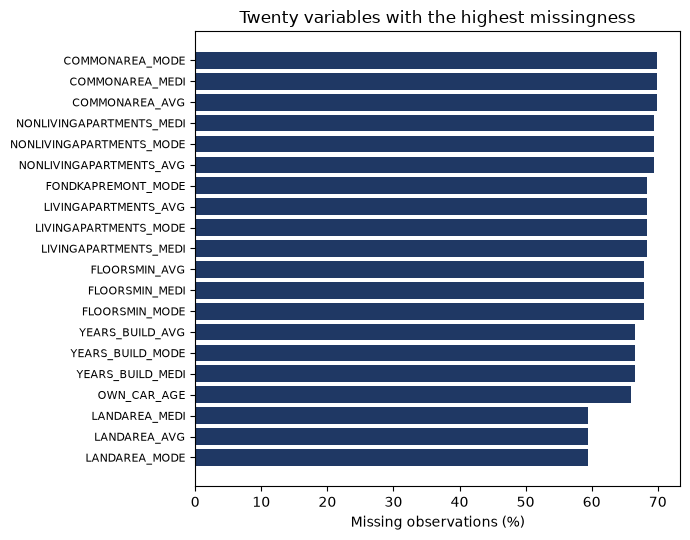

,Missing percentage
COMMONAREA_AVG,69.872231
COMMONAREA_MEDI,69.872231
COMMONAREA_MODE,69.872231
NONLIVINGAPARTMENTS_MODE,69.433216
NONLIVINGAPARTMENTS_MEDI,69.433216
NONLIVINGAPARTMENTS_AVG,69.433216
FONDKAPREMONT_MODE,68.386411
LIVINGAPARTMENTS_MEDI,68.355192
LIVINGAPARTMENTS_MODE,68.355192
LIVINGAPARTMENTS_AVG,68.355192


In [9]:
# Calculate missing values as percentages
missing_percentages = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Select the twenty variables with the most missingness
top_missing = (
    missing_percentages
    .head(20)
    .sort_values()
)

# Create the chart
fig, ax = plt.subplots(figsize=(7, 5.5))

ax.barh(
    top_missing.index,
    top_missing.values,
    color="#1f3864",
)

ax.set_xlabel("Missing observations (%)")
ax.set_title("Twenty variables with the highest missingness")
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_FOLDER, "fig_missing.png"),
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# Display the same information as a table
display(
    top_missing
    .sort_values(ascending=False)
    .rename("Missing percentage")
    .to_frame()
)

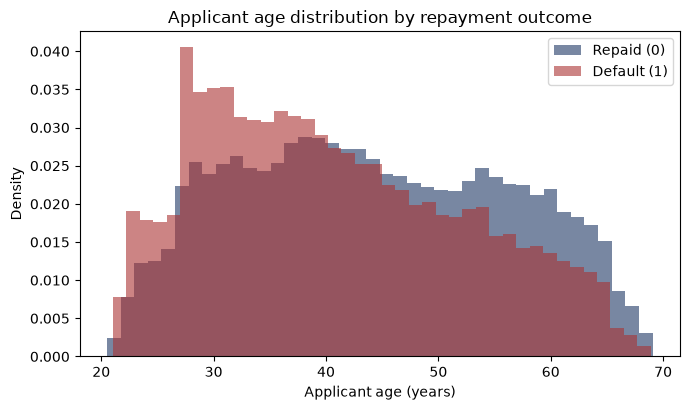

,count,mean,median,std,min,max
TARGET,,,,,,
0,282682,44.18,43.47,11.95,20.50,69.07
1,24825,40.75,39.10,11.48,21.02,68.91


In [10]:
# Convert negative birth days into age in years
applicant_age = -df["DAYS_BIRTH"] / 365.25

# Create the chart
fig, ax = plt.subplots(figsize=(7, 4.2))

ax.hist(
    applicant_age[df["TARGET"] == 0],
    bins=40,
    density=True,
    alpha=0.60,
    label="Repaid (0)",
    color="#1f3864",
)

ax.hist(
    applicant_age[df["TARGET"] == 1],
    bins=40,
    density=True,
    alpha=0.60,
    label="Default (1)",
    color="#a33",
)

ax.set_xlabel("Applicant age (years)")
ax.set_ylabel("Density")
ax.set_title("Applicant age distribution by repayment outcome")
ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_FOLDER, "fig_age.png"),
    dpi=150,
    bbox_inches="tight",
)

plt.show()

# Create a numerical summary of age by target class
age_summary = pd.DataFrame({
    "Age": applicant_age,
    "TARGET": df["TARGET"],
}).groupby("TARGET")["Age"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

display(age_summary.round(2))

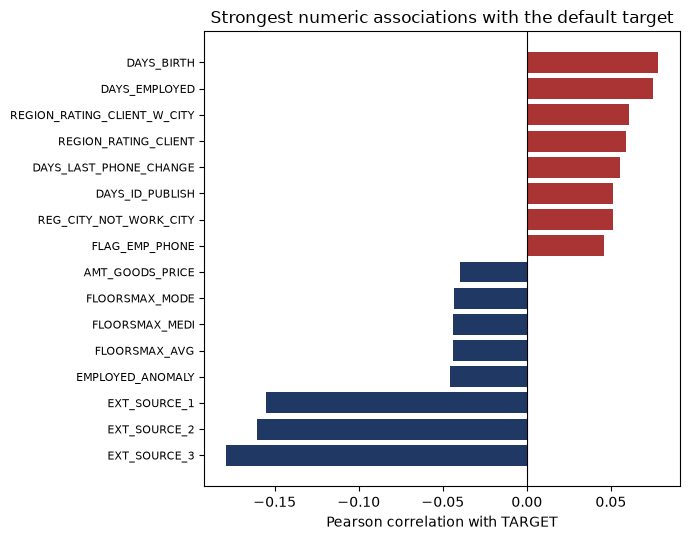

,Correlation with TARGET
DAYS_BIRTH,0.078242
DAYS_EMPLOYED,0.074957
REGION_RATING_CLIENT_W_CITY,0.060895
REGION_RATING_CLIENT,0.058901
DAYS_LAST_PHONE_CHANGE,0.055219
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050992
FLAG_EMP_PHONE,0.045984
AMT_GOODS_PRICE,-0.039647
FLOORSMAX_MODE,-0.043231


In [11]:
# Select numeric variables and remove the applicant identifier
numeric_data = (
    df.select_dtypes(include=[np.number])
    .drop(
        columns=["SK_ID_CURR"],
        errors="ignore",
    )
)

# Calculate Pearson correlations with TARGET
target_correlations = (
    numeric_data
    .corr(numeric_only=True)["TARGET"]
    .drop("TARGET")
    .dropna()
)

# Select the strongest negative and positive associations
strongest_negative = target_correlations.nsmallest(8)
strongest_positive = target_correlations.nlargest(8)

selected_correlations = (
    pd.concat(
        [strongest_negative, strongest_positive]
    )
    .drop_duplicates()
    .sort_values()
)

# Set bar colours according to the direction
correlation_colours = [
    "#1f3864" if value < 0 else "#a33"
    for value in selected_correlations.values
]

# Create the chart
fig, ax = plt.subplots(figsize=(7, 5.5))

ax.barh(
    selected_correlations.index,
    selected_correlations.values,
    color=correlation_colours,
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8,
)

ax.set_xlabel("Pearson correlation with TARGET")
ax.set_title("Strongest numeric associations with the default target")
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_FOLDER, "fig_corr.png"),
    dpi=150,
    bbox_inches="tight",
)

plt.show()

display(
    selected_correlations
    .sort_values(ascending=False)
    .rename("Correlation with TARGET")
    .to_frame()
)

In [12]:
# Store the binary target
y = df["TARGET"].astype(int)

# Remove the target and applicant identifier from the predictors
X = df.drop(
    columns=["TARGET", "SK_ID_CURR"]
)

# Identify categorical columns before encoding
categorical_columns = (
    X.select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

print(
    f"Categorical variables before encoding: "
    f"{len(categorical_columns):,}"
)

# Convert categorical variables into binary indicators
#
# This transformation does not use TARGET, so it does not introduce
# outcome leakage. Median imputation and scaling are fitted separately
# within each cross-validation fold.
X = pd.get_dummies(
    X,
    dummy_na=True,
    dtype=np.uint8,
)

# Remove characters that may be rejected by XGBoost
X.columns = [
    re.sub(
        r"[\[\]<>]",
        "_",
        str(column_name),
    )
    for column_name in X.columns
]

# Check for duplicate columns after cleaning
if X.columns.duplicated().any():
    duplicated_columns = (
        X.columns[X.columns.duplicated()]
        .unique()
        .tolist()
    )

    raise ValueError(
        "Cleaning produced duplicate feature names. "
        f"Examples: {duplicated_columns[:10]}"
    )

# Convert all predictors to float32 to reduce memory usage
X = X.astype(np.float32)

# Treat infinite values as missing
X = X.replace(
    [np.inf, -np.inf],
    np.nan,
)

print(f"Predictors after encoding: {X.shape,}")
print(f"Modelling observations: {X.shape,}")

C:\Users\USER\AppData\Local\Temp\ipykernel_18660\1751486801.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(


Categorical variables before encoding: 16
Predictors after encoding: ((307507, 260),)
Modelling observations: ((307507, 260),)


In [13]:
# Create a stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(
    f"Training data: {X_train.shape,} rows "
    f"and {X_train.shape,} predictors."
)

print(
    f"Test data: {X_test.shape,} rows "
    f"and {X_test.shape,} predictors."
)

print(f"Training default rate: {y_train.mean():.4f}")
print(f"Test default rate: {y_test.mean():.4f}")

Training data: ((246005, 260),) rows and ((246005, 260),) predictors.
Test data: ((61502, 260),) rows and ((61502, 260),) predictors.
Training default rate: 0.0807
Test default rate: 0.0807


In [18]:
# Calculate the negative-to-positive class ratio for XGBoost
scale_positive_weight = (
    (y_train == 0).sum()
    / (y_train == 1).sum()
)
print(
    f"XGBoost scale_pos_weight: "
    f"{scale_positive_weight:.2f}"
)


def make_pipeline(model, scale_features=False):
    """
    Construct a modelling pipeline.
    All three models receive median imputation.
    Logistic Regression also receives standardisation because its
    coefficients are affected by predictor scale.
    Keeping these operations inside the pipeline prevents information from
    validation folds influencing fitted imputation and scaling parameters.
    set_output keeps pandas column names, which SHAP needs later.
    """
    # Begin with median imputation
    steps = [
        (
            "imputer",
            SimpleImputer(strategy="median"),
        )
    ]
    # Standardise only where required
    if scale_features:
        steps.append(
            (
                "scaler",
                StandardScaler(),
            )
        )
    # Add the classifier
    steps.append(
        (
            "classifier",
            model,
        )
    )
    return Pipeline(steps).set_output(transform="pandas")


# Define the three model pipelines
#
# These are baseline specifications rather than formally optimised
# hyperparameters.
model_pipelines = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=RANDOM_STATE,
        ),
        scale_features=True,
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=20,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        scale_features=False,
    ),
    "XGBoost": make_pipeline(
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.10,
            max_depth=6,
            scale_pos_weight=scale_positive_weight,
            eval_metric="auc",
            tree_method="hist",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        scale_features=False,
    ),
}
print("The three model pipelines have been defined.")

XGBoost scale_pos_weight: 11.39
The three model pipelines have been defined.


In [19]:
def calculate_scores(
    y_true,
    model_scores,
    threshold=0.50,
):
    """
    Calculate performance measures from a vector of model scores.

    The supplied threshold converts the scores into predicted classes.

    Average precision is included because the default class is uncommon
    and minority-class performance is important.
    """

    # Convert scores into binary predictions
    predicted_classes = (
        model_scores >= threshold
    ).astype(int)

    return {
        "roc_auc": roc_auc_score(
            y_true,
            model_scores,
        ),

        "average_precision": average_precision_score(
            y_true,
            model_scores,
        ),

        "precision": precision_score(
            y_true,
            predicted_classes,
            zero_division=0,
        ),

        "recall": recall_score(
            y_true,
            predicted_classes,
            zero_division=0,
        ),

        "f1": f1_score(
            y_true,
            predicted_classes,
            zero_division=0,
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            predicted_classes,
        ),
    }

In [21]:
# Create five stratified folds
cross_validation = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# Save the exact splits so all models use identical folds
cv_splits = list(
    cross_validation.split(
        X_train,
        y_train,
    )
)

# Convert the training target to an array for fold indexing
y_train_array = y_train.to_numpy()

# Containers for the results
cv_rows = []
out_of_fold_scores = {}

print(f"Created {len(cv_splits)} stratified cross-validation folds.")

# Confirm each fold preserves the default rate
for fold_number, (train_idx, test_idx) in enumerate(cv_splits, start=1):
    print(
        f"Fold {fold_number}: "
        f"{len(test_idx):,} validation rows, "
        f"default rate {y_train_array[test_idx].mean():.4f}"
    )

Created 5 stratified cross-validation folds.
Fold 1: 49,201 validation rows, default rate 0.0807
Fold 2: 49,201 validation rows, default rate 0.0807
Fold 3: 49,201 validation rows, default rate 0.0807
Fold 4: 49,201 validation rows, default rate 0.0807
Fold 5: 49,201 validation rows, default rate 0.0807


In [22]:
# Evaluate each model on identical folds

# Start from an empty results list so the cell can be safely rerun
cv_rows = []

for model_name, model_pipeline in model_pipelines.items():

    start_time = time.time()

    # Generate out-of-fold scores
    #
    # Every training applicant is predicted by a model that was not fitted
    # using that applicant.
    model_oof_scores = cross_val_predict(
        model_pipeline,
        X_train,
        y_train,
        cv=cv_splits,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]

    # Retain the out-of-fold scores for threshold selection
    out_of_fold_scores[model_name] = model_oof_scores

    # Calculate metrics separately for every validation fold
    fold_scores = []

    for _, validation_indices in cv_splits:
        fold_result = calculate_scores(
            y_train_array[validation_indices],
            model_oof_scores[validation_indices],
            threshold=0.50,
        )

        fold_scores.append(fold_result)

    # Convert fold results to a table
    fold_scores_table = pd.DataFrame(fold_scores)

    # Summarise this model
    summary_row = {
        "model": model_name,
    }

    for metric_name in fold_scores_table.columns:
        summary_row[f"{metric_name}_mean"] = (
            fold_scores_table[metric_name].mean()
        )

        summary_row[f"{metric_name}_sd"] = (
            fold_scores_table[metric_name].std(ddof=1)
        )

    cv_rows.append(summary_row)

    elapsed_time = time.time() - start_time

    print(
        f"\n{model_name}: five-fold cross-validation "
        f"({elapsed_time:.0f} seconds)"
    )

    for metric_name in fold_scores_table.columns:
        metric_mean = fold_scores_table[metric_name].mean()
        metric_sd = fold_scores_table[metric_name].std(ddof=1)

        print(
            f"  {metric_name:20s}: "
            f"{metric_mean:.4f} "
            f"(SD {metric_sd:.4f})"
        )


# Create the complete model-comparison table
cv_results_table = (
    pd.DataFrame(cv_rows)
    .set_index("model")
    .round(4)
)

# Save the results
cv_results_table.to_csv(
    os.path.join(OUTPUT_FOLDER, "cv_results.csv")
)

display(cv_results_table)


Logistic Regression: five-fold cross-validation (111 seconds)
  roc_auc             : 0.7451 (SD 0.0024)
  average_precision   : 0.2191 (SD 0.0062)
  precision           : 0.1601 (SD 0.0013)
  recall              : 0.6758 (SD 0.0043)
  f1                  : 0.2588 (SD 0.0018)
  balanced_accuracy   : 0.6822 (SD 0.0021)

Random Forest: five-fold cross-validation (387 seconds)
  roc_auc             : 0.7414 (SD 0.0008)
  average_precision   : 0.2155 (SD 0.0061)
  precision           : 0.1901 (SD 0.0021)
  recall              : 0.5268 (SD 0.0056)
  f1                  : 0.2794 (SD 0.0027)
  balanced_accuracy   : 0.6649 (SD 0.0027)

XGBoost: five-fold cross-validation (195 seconds)
  roc_auc             : 0.7486 (SD 0.0025)
  average_precision   : 0.2330 (SD 0.0052)
  precision           : 0.1781 (SD 0.0024)
  recall              : 0.6075 (SD 0.0099)
  f1                  : 0.2754 (SD 0.0037)
  balanced_accuracy   : 0.6806 (SD 0.0047)


,roc_auc_mean,roc_auc_sd,average_precision_mean,average_precision_sd,precision_mean,precision_sd,recall_mean,recall_sd,f1_mean,f1_sd,balanced_accuracy_mean,balanced_accuracy_sd
model,,,,,,,,,,,,
Logistic Regression,0.7451,0.0024,0.2191,0.0062,0.1601,0.0013,0.6758,0.0043,0.2588,0.0018,0.6822,0.0021
Random Forest,0.7414,0.0008,0.2155,0.0061,0.1901,0.0021,0.5268,0.0056,0.2794,0.0027,0.6649,0.0027
XGBoost,0.7486,0.0025,0.2330,0.0052,0.1781,0.0024,0.6075,0.0099,0.2754,0.0037,0.6806,0.0047


In [23]:
# Identify the mean ROC-AUC column
selection_column = f"{PRIMARY_METRIC}_mean"

# Select the model with the highest mean cross-validated ROC-AUC
best_model_name = cv_results_table[
    selection_column
].idxmax()

best_cv_auc = cv_results_table.loc[
    best_model_name,
    selection_column,
]

print(
    f"Preferred model: {best_model_name}"
)

print(
    f"Mean cross-validation ROC-AUC: {best_cv_auc:.4f}"
)

print(
    "\nROC-AUC was specified as the primary selection measure. "
    "Average precision, precision, recall, F1 and balanced accuracy "
    "are complementary measures."
)

Preferred model: XGBoost
Mean cross-validation ROC-AUC: 0.7486

ROC-AUC was specified as the primary selection measure. Average precision, precision, recall, F1 and balanced accuracy are complementary measures.


Secondary F1-based threshold: 0.64
Out-of-fold F1 at this threshold: 0.2998

This is a statistical threshold for balancing precision and recall. It is not presented as an optimal commercial lending threshold.


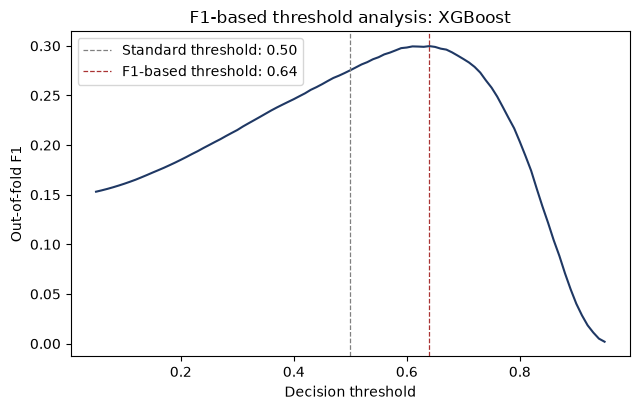

In [24]:
# Candidate thresholds
threshold_grid = np.arange(
    0.05,
    0.96,
    0.01,
)

# Retrieve the selected model's out-of-fold scores
preferred_oof_scores = out_of_fold_scores[
    best_model_name
]

# Calculate out-of-fold F1 at every threshold
threshold_f1_scores = []

for threshold in threshold_grid:
    threshold_predictions = (
        preferred_oof_scores >= threshold
    ).astype(int)

    threshold_f1 = f1_score(
        y_train_array,
        threshold_predictions,
        zero_division=0,
    )

    threshold_f1_scores.append(threshold_f1)

# Find the threshold with the highest out-of-fold F1
best_threshold_position = int(
    np.argmax(threshold_f1_scores)
)

f1_threshold = float(
    threshold_grid[best_threshold_position]
)

best_oof_f1 = float(
    threshold_f1_scores[best_threshold_position]
)

print(
    f"Secondary F1-based threshold: {f1_threshold:.2f}"
)

print(
    f"Out-of-fold F1 at this threshold: {best_oof_f1:.4f}"
)

print(
    "\nThis is a statistical threshold for balancing precision and recall. "
    "It is not presented as an optimal commercial lending threshold."
)

# Plot F1 against the threshold
fig, ax = plt.subplots(figsize=(6.5, 4.2))

ax.plot(
    threshold_grid,
    threshold_f1_scores,
    color="#1f3864",
)

ax.axvline(
    0.50,
    linestyle="--",
    linewidth=0.9,
    color="grey",
    label="Standard threshold: 0.50",
)

ax.axvline(
    f1_threshold,
    linestyle="--",
    linewidth=0.9,
    color="#a33",
    label=f"F1-based threshold: {f1_threshold:.2f}",
)

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Out-of-fold F1")
ax.set_title(
    f"F1-based threshold analysis: {best_model_name}"
)
ax.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_FOLDER, "fig_threshold.png"),
    dpi=150,
    bbox_inches="tight",
)

plt.show()

Class weighting means the conventional 0.50 cut-off is not necessarily the
best balance of precision and recall. F1 was calculated at every threshold
from 0.05 to 0.95 using out-of-fold predictions, so the test labels played
no part in the choice.

F1 peaks at 0.64, giving 0.2998 against 0.2754 at 0.50. The peak is broad,
so the result does not depend on one narrow choice. Both thresholds are
reported below. F1 treats a missed default and a wrongly declined applicant
as equally costly, so this is a statistical balance point rather than a
commercial lending threshold.


Logistic Regression: held-out test set at threshold 0.50
  roc_auc             : 0.7489
  average_precision   : 0.2278
  precision           : 0.1616
  recall              : 0.6757
  f1                  : 0.2609
  balanced_accuracy   : 0.6840

Random Forest: held-out test set at threshold 0.50
  roc_auc             : 0.7454
  average_precision   : 0.2226
  precision           : 0.1920
  recall              : 0.5329
  f1                  : 0.2823
  balanced_accuracy   : 0.6680

XGBoost: held-out test set at threshold 0.50
  roc_auc             : 0.7562
  average_precision   : 0.2465
  precision           : 0.1778
  recall              : 0.6232
  f1                  : 0.2766
  balanced_accuracy   : 0.6850

XGBoost: held-out test set at F1-based threshold 0.64
  roc_auc             : 0.7562
  average_precision   : 0.2465
  precision           : 0.2397
  recall              : 0.4165
  f1                  : 0.3043
  balanced_accuracy   : 0.6503


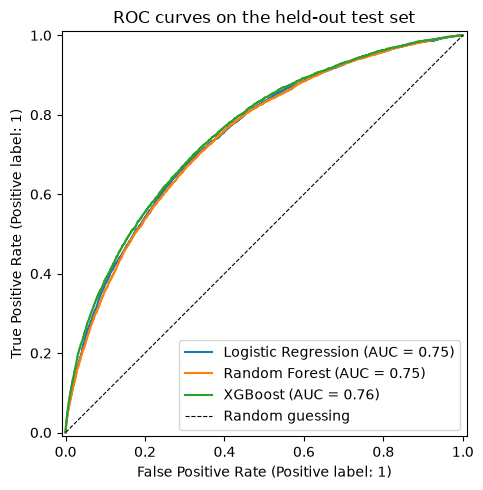

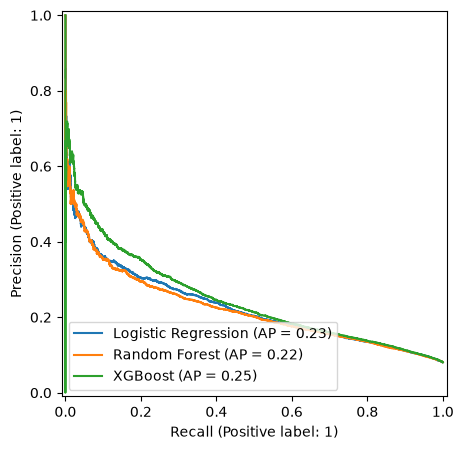

,model,threshold_type,threshold,roc_auc,average_precision,precision,recall,f1,balanced_accuracy
0,Logistic Regression,standard,0.50,0.7489,0.2278,0.1616,0.6757,0.2609,0.6840
1,Random Forest,standard,0.50,0.7454,0.2226,0.1920,0.5329,0.2823,0.6680
2,XGBoost,standard,0.50,0.7562,0.2465,0.1778,0.6232,0.2766,0.6850
3,XGBoost,f1_based,0.64,0.7562,0.2465,0.2397,0.4165,0.3043,0.6503


In [25]:
# Evaluation on the held-out test set. Containers for fitted models and final results
fitted_pipelines = {}
test_rows = []
# Shared ROC and precision-recall charts
fig_roc, ax_roc = plt.subplots(figsize=(6.5, 5))
fig_pr, ax_pr = plt.subplots(figsize=(6.5, 5))
for model_name, model_pipeline in model_pipelines.items():
    # Fit the model using the complete training dataset
    model_pipeline.fit(
        X_train,
        y_train,
    )
    fitted_pipelines[model_name] = model_pipeline
    # Obtain the estimated default scores/probabilities
    #
    # Class weighting can affect probability calibration, so these outputs
    # are used primarily for ranking and classification.
    test_scores = model_pipeline.predict_proba(
        X_test
    )[:, 1]
    # Evaluate at the standard threshold
    standard_results = calculate_scores(
        y_test,
        test_scores,
        threshold=0.50,
    )
    standard_results.update(
        {
            "model": model_name,
            "threshold_type": "standard",
            "threshold": 0.50,
        }
    )
    test_rows.append(standard_results)
    print(
        f"\n{model_name}: held-out test set "
        "at threshold 0.50"
    )
    for metric_name in [
        "roc_auc",
        "average_precision",
        "precision",
        "recall",
        "f1",
        "balanced_accuracy",
    ]:
        print(
            f"  {metric_name:20s}: "
            f"{standard_results[metric_name]:.4f}"
        )
    # Evaluate only the selected model at the F1-based threshold
    if model_name == best_model_name:
        tuned_results = calculate_scores(
            y_test,
            test_scores,
            threshold=f1_threshold,
        )
        tuned_results.update(
            {
                "model": model_name,
                "threshold_type": "f1_based",
                "threshold": f1_threshold,
            }
        )
        test_rows.append(tuned_results)
        print(
            f"\n{model_name}: held-out test set "
            f"at F1-based threshold {f1_threshold:.2f}"
        )
        for metric_name in [
            "roc_auc",
            "average_precision",
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
        ]:
            print(
                f"  {metric_name:20s}: "
                f"{tuned_results[metric_name]:.4f}"
            )
    # Add this model to the ROC chart
    RocCurveDisplay.from_predictions(
        y_test,
        test_scores,
        name=model_name,
        ax=ax_roc,
    )
    # Add this model to the precision-recall chart
    PrecisionRecallDisplay.from_predictions(
        y_test,
        test_scores,
        name=model_name,
        ax=ax_pr,
    )
# Complete and save the ROC chart
ax_roc.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=0.8,
    label="Random guessing",
)
ax_roc.legend(loc="lower right")
ax_roc.set_title(
    "ROC curves on the held-out test set"
)
fig_roc.tight_layout()
fig_roc.savefig(
    os.path.join(OUTPUT_FOLDER, "fig_roc.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()
# Add the no-skill baseline to the precision-recall chart
ax_pr.axhline(
    y_test.mean(),
    linestyle="--",
    linewidth=0.8,
    color="black",
    label=f"No-skill baseline ({y_test.mean():.3f})",
)
ax_pr.legend(loc="upper right")
ax_pr.set_title(
    "Precision-recall curves on the held-out test set"
)
fig_pr.tight_layout()
fig_pr.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "fig_precision_recall.png",
    ),
    dpi=150,
    bbox_inches="tight",
)
plt.show()
# Convert the results into a table
test_results_table = pd.DataFrame(test_rows)
test_results_table = test_results_table[
    [
        "model",
        "threshold_type",
        "threshold",
        "roc_auc",
        "average_precision",
        "precision",
        "recall",
        "f1",
        "balanced_accuracy",
    ]
].round(4)
# Save the final test results
test_results_table.to_csv(
    os.path.join(OUTPUT_FOLDER, "test_results.csv"),
    index=False,
)
display(test_results_table)

ROC and precision-recall curves on the held-out test set

The ROC curves show all three models rank applicants far better than chance, with XGBoost highest at 0.76.
The precision-recall curves matter more here, because only 8.07% of applicants default, and they show a
smaller gap. XGBoost reaches 0.25 average precision, compared with 0.22 for the baseline. So the advanced model
is better, but not by a wide margin, which matches what earlier benchmark studies have reported.

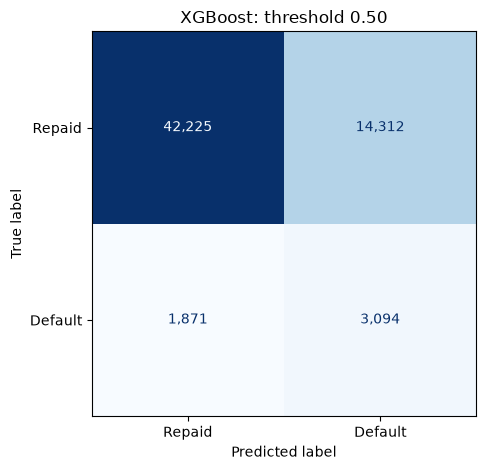


Threshold 0.50: 3,094 defaulters correctly identified, 1,871 missed, 14,312 repayers wrongly flagged.


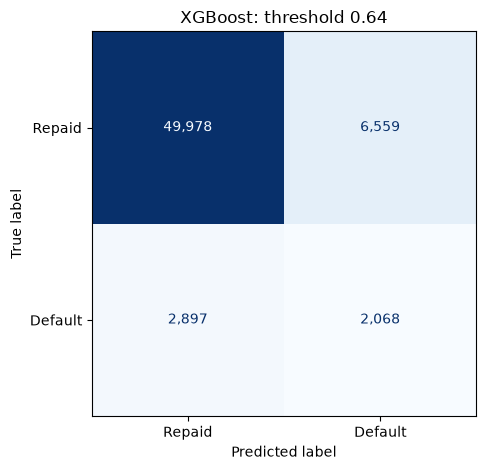


Threshold 0.64: 2,068 defaulters correctly identified, 2,897 missed, 6,559 repayers wrongly flagged.


In [26]:
# Retrieve the fitted selected pipeline
best_fitted_pipeline = fitted_pipelines[
    best_model_name
]

# Calculate its test scores once
best_test_scores = (
    best_fitted_pipeline
    .predict_proba(X_test)[:, 1]
)

# Define the thresholds to compare
confusion_thresholds = [
    (0.50, "standard_050"),
    (f1_threshold, "f1_based"),
]

for threshold, filename_tag in confusion_thresholds:

    # Convert scores to class predictions
    predicted_classes = (
        best_test_scores >= threshold
    ).astype(int)

    # Calculate the confusion matrix
    matrix = confusion_matrix(
        y_test,
        predicted_classes,
    )

    # Display the confusion matrix
    display_object = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Repaid", "Default"],
    )

    display_object.plot(
        values_format=",d",
        colorbar=False,
        cmap="Blues",
    )

    plt.title(
        f"{best_model_name}: threshold {threshold:.2f}"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_FOLDER,
            f"fig_confusion_{filename_tag}.png",
        ),
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

# Report the four cell counts in words
    true_negative, false_positive, false_negative, true_positive = matrix.ravel()
    print(
        f"\nThreshold {threshold:.2f}: "
        f"{true_positive:,} defaulters correctly identified, "
        f"{false_negative:,} missed, "
        f"{false_positive:,} repayers wrongly flagged."
    )

Confusion matrices for XGBoost at both thresholds

At the standard 0.50 threshold, the model finds 3,094 of the 4,963 defaulters, but wrongly flags 14,312
applicants who would have repaid. Raising the threshold to 0.64 cuts those wrong flags to 6,559, at the
cost of catching 1,026 fewer defaulters. In other words, one real default is missed for roughly every
seven good customers no longer turned away. Which balance is right depends on what each error costs the
lender, so both are reported here.

In [27]:
# Extract the preprocessing part of the fitted selected pipeline
selected_preprocessor = best_fitted_pipeline[:-1]
# Apply the same fitted transformations to the train and test data
#
# set_output was configured on the pipeline, so these are already DataFrames
# with the correct feature names.
X_test_transformed = selected_preprocessor.transform(X_test)
X_train_transformed = selected_preprocessor.transform(X_train)
# Retrieve the fitted classifier
selected_classifier = (
    best_fitted_pipeline
    .named_steps["classifier"]
)
# Determine the sample size
actual_shap_sample_size = min(
    SHAP_SAMPLE_SIZE,
    len(X_test_transformed),
)
# Draw a reproducible sample
shap_sample = X_test_transformed.sample(
    n=actual_shap_sample_size,
    random_state=RANDOM_STATE,
)
print(f"Selected model: {best_model_name}")
print(
    f"SHAP sample: {actual_shap_sample_size:,} "
    "test observations."
)

Selected model: XGBoost
SHAP sample: 1,000 test observations.


In [28]:
# Logistic Regression requires a linear SHAP explainer
if best_model_name == "Logistic Regression":
    # Draw a smaller background sample from the training set
    background_size = min(
        200,
        len(X_train_transformed),
    )
    shap_background = X_train_transformed.sample(
        n=background_size,
        random_state=RANDOM_STATE,
    )
    # Create the linear explainer
    shap_explainer = shap.LinearExplainer(
        selected_classifier,
        shap_background,
    )
    # Calculate SHAP values
    shap_values = shap_explainer(
        shap_sample
    )
# Random Forest and XGBoost use TreeExplainer
else:
    # Create the tree-specific explainer
    #
    # No background dataset is supplied, so SHAP uses the fast
    # path-dependent algorithm designed for tree models.
    shap_explainer = shap.TreeExplainer(
        selected_classifier
    )
    # Calculate SHAP values
    shap_values = shap_explainer(
        shap_sample
    )
# Some binary classifiers return a separate explanation for each class.
# Keep the positive class representing default.
if shap_values.values.ndim == 3:
    shap_values = shap_values[:, :, 1]
print(
    f"SHAP values calculated for "
    f"{shap_values.values.shape[0]:,} applicants "
    f"across {shap_values.values.shape[1]:,} features."
)

SHAP values calculated for 1,000 applicants across 260 features.


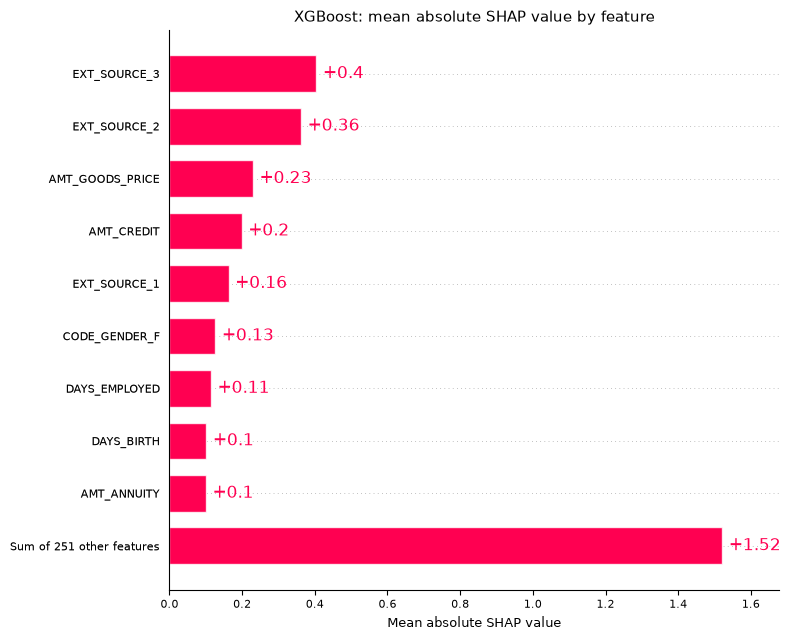

In [30]:
# Plot the mean absolute SHAP values
## This chart identifies the features making the largest average contributions to the model's predictions.
# It does not show whether high values increase or decrease predicted risk.
plt.figure(figsize=(7, 4.5))
shap.plots.bar(
    shap_values,
    max_display=10,
    show=False,
)
plt.title(
    f"{best_model_name}: mean absolute SHAP value by feature",
    fontsize=11,
)
plt.tick_params(axis="y", labelsize=8)
plt.tick_params(axis="x", labelsize=8)
plt.xlabel("Mean absolute SHAP value", fontsize=9)
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_FOLDER, "fig_shap_bar.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

The three EXT_SOURCE variables are normalised scores from external data providers, and Home Credit does not disclose their origin or construction

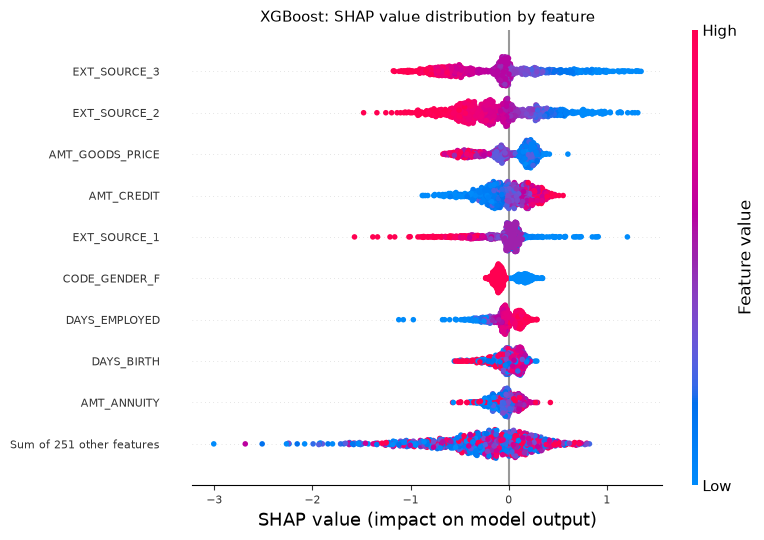

In [31]:
# SHAP beeswarm chart. Plot feature importance and direction of contribution
plt.figure(figsize=(7, 4.5))
shap.plots.beeswarm(
    shap_values,
    max_display=10,
    show=False,
)
plt.title(
    f"{best_model_name}: SHAP value distribution by feature",
    fontsize=11,
)
plt.tick_params(axis="y", labelsize=8)
plt.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "fig_shap_beeswarm.png",
    ),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

##### SHAP value distribution for the ten most influential features

Each point is one applicant out of the 1,000. If a point sits to the right, that feature
pushed the model's predicted risk up for that person. To the left, it pushed the risk down. The colour
tells you what that applicant's own value was: red for high, blue for low.

Gender appears among the top features, with female applicants associated
with lower predicted risk. 


In [34]:
##### Checking one applicant's SHAP values
print(shap_values.values[0][:5])
print(shap_sample.iloc[0, :5])

[ 0.0006265  -0.00348123 -0.22021721  0.02142776  0.24438001]
CNT_CHILDREN             1.0
AMT_INCOME_TOTAL    157500.0
AMT_CREDIT          225000.0
AMT_ANNUITY          18171.0
AMT_GOODS_PRICE     225000.0
Name: 94030, dtype: float32


This is a test on one applicant whose ID is 94030. The first line is what the model did
with each feature, and the second line is that applicant's actual data. Reading them together, having one
child made almost no difference, their income nudged the predicted risk down very slightly, and their
annuity nudged it up slightly. The two large numbers are the credit amount, which pushed the predicted
risk down by 0.22, and the goods price, which pushed it up by 0.24.

Both of those amounts are the same figure of 225,000, so the two effects almost cancel each other out.
This is a small illustration of the pattern seen across the whole sample, where the model appears to
respond to the loan amount relative to what is being bought rather than to either figure on its own.

This check is included because it shows what the beeswarm chart is built from. Every point on that chart
is one number of this kind, for one applicant and one feature. The values are on the model's log-odds
scale rather than being probabilities, so they show the size and direction of each contribution rather
than a percentage.

Explaining applicant 255361, predicted default probability 0.920


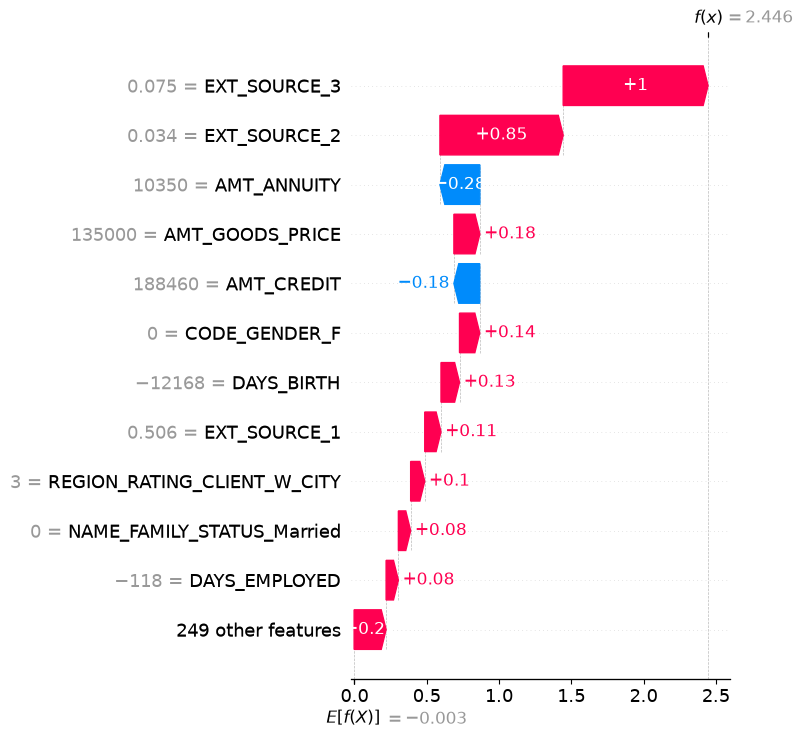

In [42]:
# SHAP local waterfall chart
#
# The applicant explained here is the one the model scored as highest risk
# in the sample, chosen because a clear case illustrates the method better
# than an average one.
sample_scores = best_fitted_pipeline.predict_proba(
    X_test.loc[shap_sample.index]
)[:, 1]
highest_risk_position = int(np.argmax(sample_scores))

print(
    f"Explaining applicant {shap_sample.index[highest_risk_position]}, "
    f"predicted default probability "
    f"{sample_scores[highest_risk_position]:.3f}"
)
plt.figure(figsize=(7, 5))
shap.plots.waterfall(
    shap_values[highest_risk_position],
    max_display=12,
    show=False,
)
plt.gca().tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig(
    os.path.join(
        OUTPUT_FOLDER,
        "fig_shap_waterfall.png",
    ),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

This applicant received a predicted default probability of 0.920. The chart starts at the average
prediction and shows what moved this person's score, with their values listed on the left.
Two very low external scores did most of the work, adding 1.0 and 0.85 between them. Smaller factors
built on top: the loan of 188,460 exceeds the 135,000 goods price, the applicant is 33, and they have
been employed for only four months. Stated income is not among the twelve features shown, which reflects
how heavily this model leans on external scores rather than on income alone.

In [38]:
# Pull the headline test results for the selected model
#
# These are read from the results table rather than typed in, so the saved
# summary always matches what the model actually scored.
best_standard_row = test_results_table.loc[
    (test_results_table["model"] == best_model_name)
    & (test_results_table["threshold_type"] == "standard")
].iloc[0]
# Save the complete fitted pipeline, including preprocessing
#
# Saving the whole pipeline means the imputation and scaling are stored with
# the model, so it can score new data without rebuilding those steps.
joblib.dump(
    best_fitted_pipeline,
    os.path.join(
        OUTPUT_FOLDER,
        "best_model_pipeline.joblib",
    ),
)
# Save the ordered feature names
#
# Taken from the fitted pipeline itself, so the list is exactly what the
# model expects and in the right order.
pd.Series(
    best_fitted_pipeline.feature_names_in_,
    name="feature_name",
).to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "model_feature_names.csv",
    ),
    index=False,
)
# Create a summary of the main modelling choices and results
model_summary = pd.DataFrame(
    {
        "Setting": [
            "Selected model",
            "Primary selection metric",
            "Cross-validation folds",
            "Random state",
            "Standard threshold",
            "F1-based threshold",
            "Training default rate",
            "Test default rate",
            "SHAP sample size",
            "Test ROC-AUC",
            "Test average precision",
        ],
        "Value": [
            best_model_name,
            "Mean cross-validation ROC-AUC",
            N_FOLDS,
            RANDOM_STATE,
            0.50,
            f1_threshold,
            round(y_train.mean(), 4),
            round(y_test.mean(), 4),
            actual_shap_sample_size,
            best_standard_row["roc_auc"],
            best_standard_row["average_precision"],
        ],
    }
)
# Save the model summary
model_summary.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "model_summary.csv",
    ),
    index=False,
)
display(model_summary)

# I want to check the saved model size before adding it to version control
# GitHub rejects files above 100 MB, so this determines whether the model is committed or regenerated from the notebook.
model_file_path = os.path.join(
    OUTPUT_FOLDER,
    "best_model_pipeline.joblib",
)
model_size_mb = os.path.getsize(model_file_path) / 1e6
print(f"Saved model file size: {model_size_mb:.1f} MB")

,Setting,Value
0,Selected model,XGBoost
1,Primary selection metric,Mean cross-validation ROC-AUC
2,Cross-validation folds,5
3,Random state,42
4,Standard threshold,0.5
5,F1-based threshold,0.64
6,Training default rate,0.0807
7,Test default rate,0.0807
8,SHAP sample size,1000
9,Test ROC-AUC,0.7562


Saved model file size: 1.2 MB


In [43]:
print("Pipeline complete.")

print(f"Selected model: {best_model_name}")

print("Standard reporting threshold: 0.50")

print(
    f"Secondary F1-based threshold: "
    f"{f1_threshold:.2f}"
)

print(
    "\nInterpretation caution:"
)

print(
    "- Class weighting may affect probability calibration."
)

print(
    "- Model outputs are used primarily for ranking and classification."
)

print(
    "- SHAP values explain model behaviour, not causal relationships."
)


Pipeline complete.
Selected model: XGBoost
Standard reporting threshold: 0.50
Secondary F1-based threshold: 0.64

Interpretation caution:
- Class weighting may affect probability calibration.
- Model outputs are used primarily for ranking and classification.
- SHAP values explain model behaviour, not causal relationships.
